The results from this notebook are shown in Figure 9 in the paper. 

The initial inspiration for this plot was from https://academic.oup.com/mnras/article/531/4/3839/7687173. 

Note that to do this analysis, we: 
- Ignore upper limits. 
- Ignore measurement errors. 
- Only do this for the best estimates of distance. 
- The KS test is comparing the distribution of our DATA POINTS rather than the NS/BH populations (the latter would require correcting for multiple data points per source, and the fact that most NS observations are upper limits).

IMPORTANT: The figure is only meant to be illustrative, i.e. mostly for visual comparison. 

Do this analysis just for the HS/QS detections. 

In [1]:
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as nps
from scipy.stats import ks_2samp
from ndtest import ks2d2s
from matplotlib.ticker import FuncFormatter
import numpy as np

sys.path.append(os.path.abspath("../0_UTILITY_FUNCTIONS/"))
from plotting import *
from get_LrLx_data import *
from plotting import *

In [2]:
## Get the interpolated data
df = get_all_LrLx_data(interp=True, save=False, rerun=False)

Source names:  ['1A 1744-361' '4U 1543-47' '4U 1630-47' 'Aquila X-1' 'Cen X-4' 'Cir X-1'
 'EXO 1846-031' 'GRS 1739-278' 'GRS 1915+105' 'GX 339-4' 'H1743-322'
 'IGR J17091-3624' 'MAXI J1348-630' 'MAXI J1631-479' 'MAXI J1803-298'
 'MAXI J1807+132' 'MAXI J1810-222' 'MAXI J1816-195' 'MAXI J1820+070'
 'SAX J1808.4-3658' 'SAX J1810.8-2609' 'Swift J1727.8-1613'
 'Swift J1728.9-3613' 'Swift J1842.5-1124' 'Swift J1858.6-0814'
 'XTE J1701-462']


# Testing Plotting KDEs

In [3]:
states = ["HS", "QS"]

# Exclude all uplims 
mask = df["state"].isin(states) & (df["Fx_uplim_bool"]==False) & (df["Fr_uplim_bool"]==False) 
df_filtered = df[mask].copy()

# Exclude all uplims 
# To test how much the NS outlier is affecting things, add the following to mask: & (data["name"]!='MAXI J1816-195')
mask2 = df["state"].isin(states) & (df["Fx_uplim_bool"]==False) & (df["Fr_uplim_bool"]==False  & (df["name"]!='MAXI J1816-195') ) 

# Exclude all uplims and high uncertainty points
mask3 = df["state"].isin(states) & (df["Fx_uplim_bool"]==False) & (df["Fr_uplim_bool"]==False) & (df["Fr_unc"]/df["Fr"]<0.5) &  (np.maximum(df["Fx_unc_l"], df["Fx_unc_u"])/df["Fx"]<0.5) 


# Exclude Fx uplims and Fr uplims for BHs (include Fr uplims just for NSs) and high uncertainty points
mask4 = df["state"].isin(states) & (df["Fx_uplim_bool"]==False) & (df["class"].isin(["BH", "candidateBH"]) & df["Fr_uplim_bool"]==False) & (df["Fr_unc"]/df["Fr"]<0.5) &  (np.maximum(df["Fx_unc_l"], df["Fx_unc_u"])/df["Fx"]<0.5)


# Include uplims as detections
mask5 = df["state"].isin(states) 
df_filtered5 = df[mask5].copy()


In [4]:
def test_kde(df_filtered):

    ## Get the BH and NS data
    mask_NS = df_filtered["class"].isin(["NS"]) 
    mask_BH = df_filtered["class"].isin(["BH", "candidateBH"]) 
    x_NS = df_filtered["Lx"][mask_NS]
    y_NS = df_filtered["Lr"][mask_NS]
    x_BH = df_filtered["Lx"][mask_BH]
    y_BH =  df_filtered["Lr"][mask_BH]


    ## Set up the plot
    fig= plt.figure(figsize=(9,6))
    ax = fig.add_subplot(1,1,1)

    ## Plot the data
    plt.scatter(x_NS, y_NS , color=colour_NS)
    plt.scatter(x_BH, y_BH, color=colour_BH)


    levels = [0.05, 0.25, 0.6, 0.9]

    ## KDE for NSs
    sns.kdeplot(
        x=x_NS,
        y= y_NS,
        ax=ax,
        levels=levels,
        color=colour_NS,
        linewidths=1,
        fill=False,
        log_scale=(True, True)
    )

    ## KDE for BHs
    sns.kdeplot(
        x=x_BH,
        y=y_BH,
        ax=ax,
        levels=levels,
        color=colour_BH,
        linewidths=1,
        fill=False,
        log_scale=(True, True)
    )

    plt.xlim([min_Lx, max_Lx])
    plt.ylim([min_Lr,max_Lr_2])
    plt.xlabel("Lx (erg/s)")
    plt.ylabel("Lr (erg/s)")
    ax.set_yscale("log", base=10)
    ax.set_xscale("log", base=10)
    ax.xaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=10))
    ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs="auto", numticks=10))
    plt.show()


    ######
    ## Equivalent if done on a log scale

    log_x_NS = np.log10(x_NS).to_numpy()
    log_y_NS = np.log10(y_NS).to_numpy()
    log_x_BH = np.log10(x_BH).to_numpy()
    log_y_BH =  np.log10(y_BH).to_numpy()


    fig= plt.figure(figsize=(9,6))
    ax = fig.add_subplot(1,1,1)

    plt.scatter(log_x_NS, log_y_NS , color=colour_NS)
    plt.scatter(log_x_BH, log_y_BH, color=colour_BH)


    levels = [0.05, 0.25, 0.6, 0.9]

    ## KDE for NSs
    sns.kdeplot(
        x=log_x_NS,
        y= log_y_NS,
        ax=ax,
        levels=levels,
        color=colour_NS,
        linewidths=1,
        fill=False
    )

    ## KDE for BHs
    sns.kdeplot(
        x=log_x_BH,
        y=log_y_BH,
        ax=ax,
        levels=levels,
        color=colour_BH,
        linewidths=1,
        fill=False
    )

    plt.xlim([np.log10(min_Lx),np.log10(max_Lx)])
    plt.ylim([np.log10(min_Lr),np.log10(max_Lr_2)])
    plt.xlabel("log Lx (erg/s)")
    plt.ylabel("log Lr (erg/s)")
    plt.show()


    

    ## LX

    fig, (ax1, ax2) = plt.subplots(figsize=(10,4), nrows=1, ncols=2)
    ax1.hist(log_x_NS, bins=20, alpha=0.5, label='NS Lx')
    ax1.hist(log_x_BH, bins=20, alpha=0.5, label='BH Lx')
    ax1.set_xlabel('log Lx (erg/s)')
    ax1.set_ylabel('Number of observations')
    ax1.legend()    

    ax2.hist(log_x_NS, bins=8, alpha=0.5, label='NS Lx', density=True)
    ax2.hist(log_x_BH, bins=8, alpha=0.5, label='BH Lx', density=True)
    ax2.set_xlabel('log Lx (erg/s)')
    ax2.set_ylabel('Number of observations')
    ax2.legend()  

    plt.show()


    ## LR

    fig, (ax1, ax2) = plt.subplots(figsize=(10,4), nrows=1, ncols=2)
    ax1.hist(log_y_NS, bins=20, alpha=0.5, label='NS Lr')
    ax1.hist(log_y_BH, bins=20, alpha=0.5, label='BH Lr')
    ax1.set_xlabel('log Lr (erg/s)')
    ax1.set_ylabel('Number of observations')
    ax1.legend()    

    ax2.hist(log_y_NS, bins=8, alpha=0.5, label='NS Lr', density=True)
    ax2.hist(log_y_BH, bins=8, alpha=0.5, label='BH Lr', density=True)
    ax2.set_xlabel('log Lr (erg/s)')
    ax2.set_ylabel('Number of observations')
    ax2.legend()  

    plt.show()


    ## Testing 1D KS test

    pval_log_Lx = ks_2samp(log_x_NS, log_x_BH).pvalue
    pval_log_Lr = ks_2samp(log_y_NS, log_y_BH).pvalue

    print(f"KS test p-value for Lx distributions: {pval_log_Lx}")
    print(f"KS test p-value for Lr distributions: {pval_log_Lr}")

    pval_Lx = ks_2samp(x_NS, x_BH).pvalue
    pval_Lr = ks_2samp(y_NS, y_BH).pvalue

    print(f"KS test p-value for Lx distributions: {pval_Lx}")
    print(f"KS test p-value for Lr distributions: {pval_Lr}")


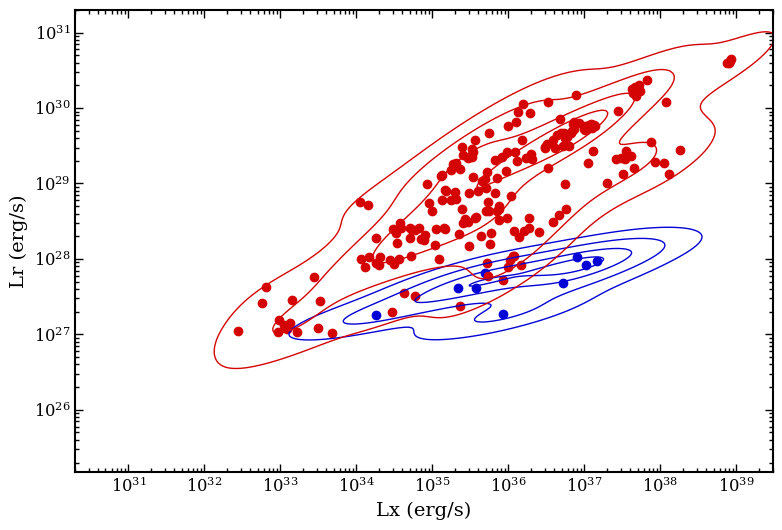

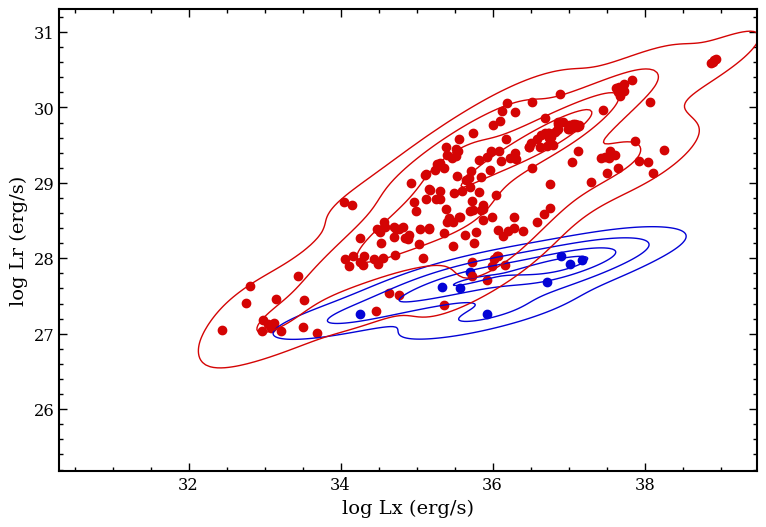

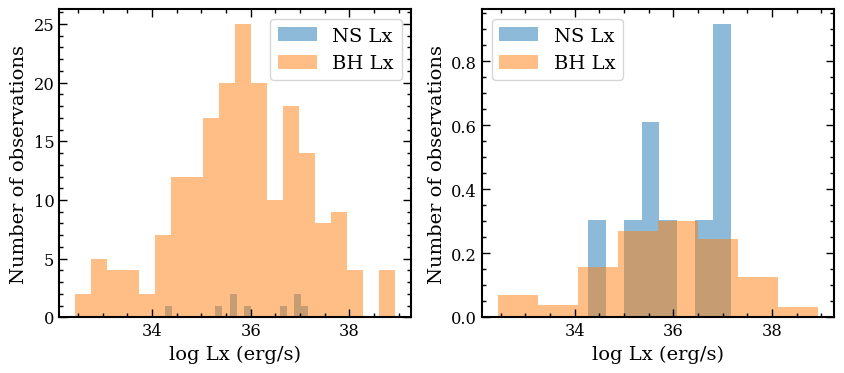

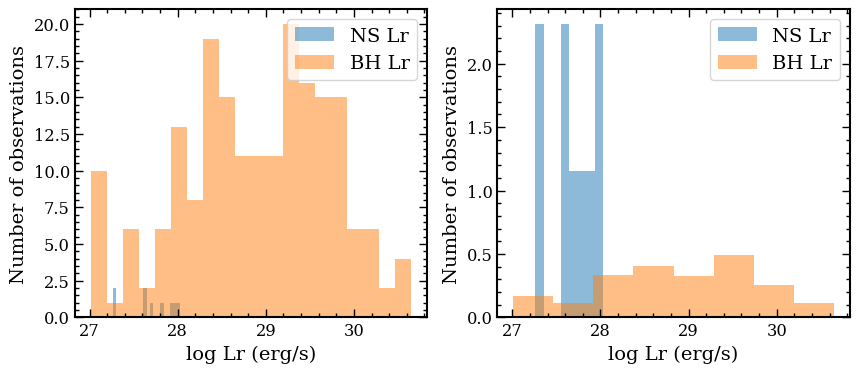

KS test p-value for Lx distributions: 0.7759273292937164
KS test p-value for Lr distributions: 9.62261292840855e-07
KS test p-value for Lx distributions: 0.7759273292937164
KS test p-value for Lr distributions: 9.62261292840855e-07


In [5]:
# Only detections
test_kde(df_filtered)

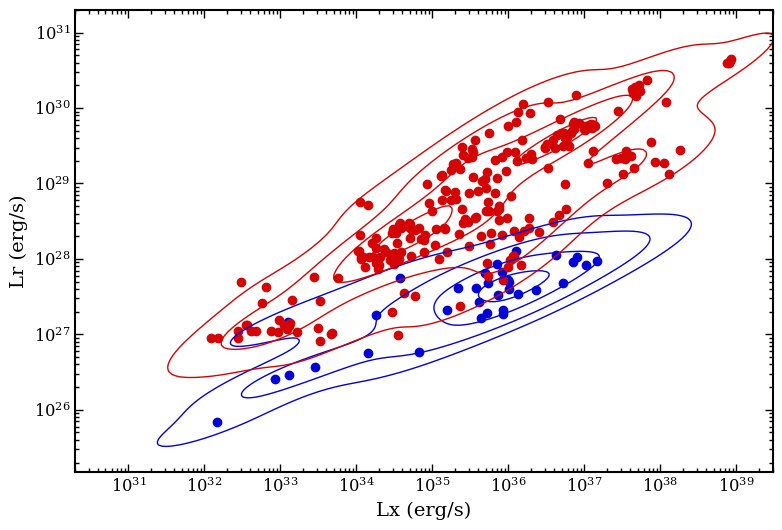

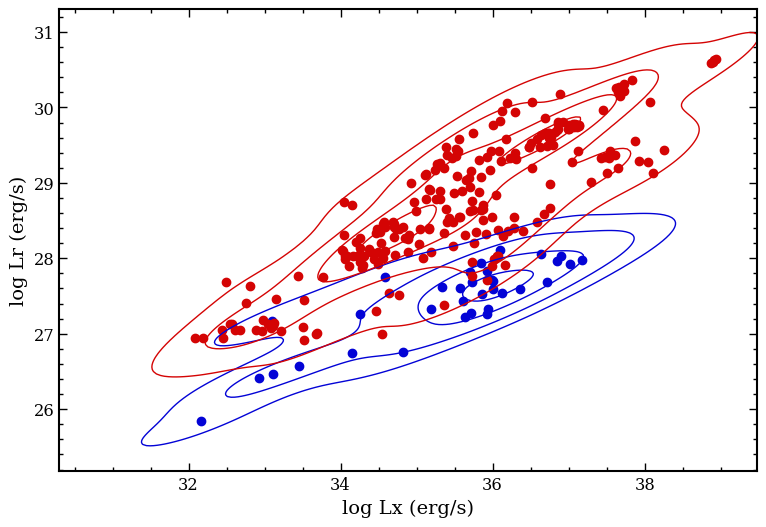

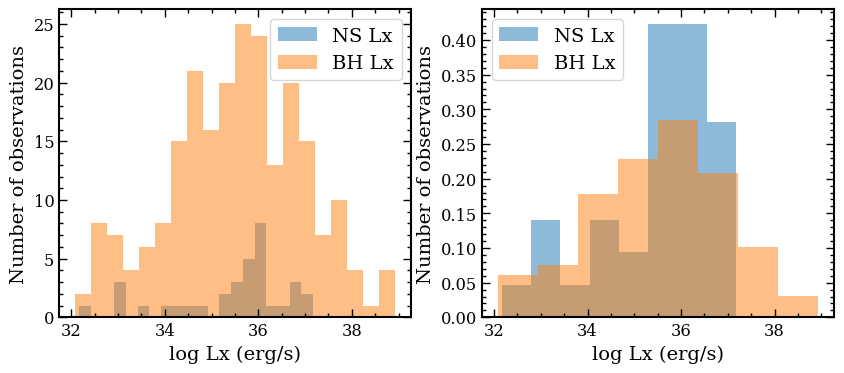

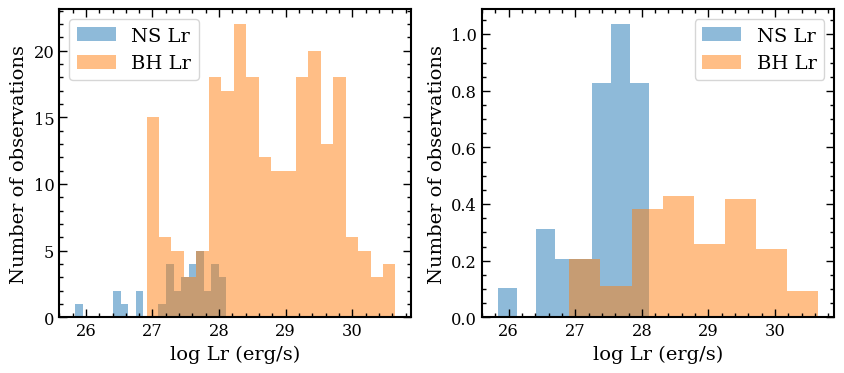

KS test p-value for Lx distributions: 0.33323285637697303
KS test p-value for Lr distributions: 2.587276964619267e-16
KS test p-value for Lx distributions: 0.33323285637697303
KS test p-value for Lr distributions: 2.587276964619267e-16


In [6]:
# Including upper limits as detections
test_kde(df_filtered5)

# Final Plot

KS test p-values: Lx=7.75927e-01, Lr=9.62261e-07, 2D=2.48048e-05
Harmonic mean p-value: 1.92452e-06
Harmonic mean p-value: 1.92452e-06


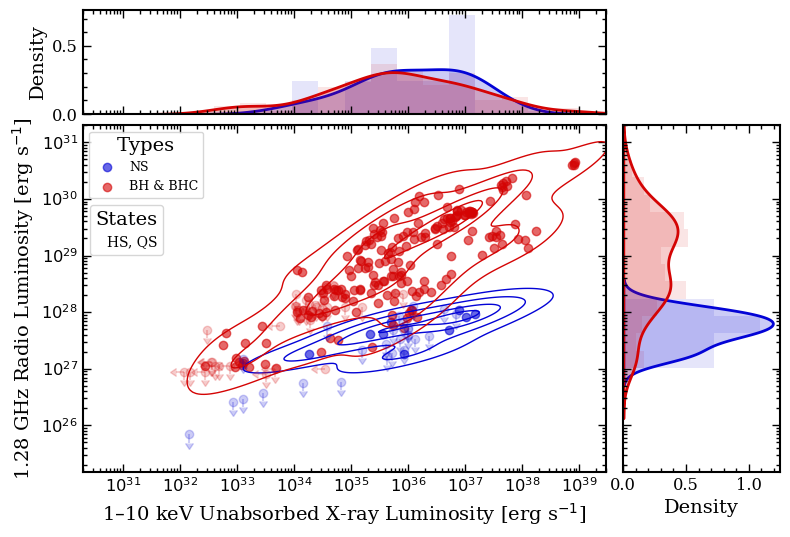

In [7]:
plot_LrLx_comparison(df, plot_type="BH_vs_NS")

---



# Dealing with multiple data points per source

This is for illustrative purposes, since Monte Carlo sampling on the p-value is not very scientific. 

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, chi2
import matplotlib.pyplot as plt

In [11]:
def summarize_pvals(pvals, name, thresholds=(0.05, 0.01, 0.001)):
    pvals = pvals[np.isfinite(pvals)]  # remove NaNs
    n = len(pvals)
    print(f"\n{name}")
    print(f"Valid iterations: {n}")

    for t in thresholds:
        frac = np.mean(pvals < t)
        print(f"Fraction with p < {t}: {100*frac:.2f}%")

    print(f"Median p-value: {np.median(pvals):.3e}")
    print(f"Mean p-value:   {np.mean(pvals):.3e}")



def repeated_random_source_sampling_ks(df, n_iter=2000, random_seed=None, plot=False):
    """
    For n_iter times:
      - randomly sample one row per unique source (column source_col)
      - apply the same masking logic as your snippet to build detection-only samples
      - compute KS p-values for log10(Lx) and log10(Lr) between group1 and group2 (detections only)
      - compute Fisher combined p-value (optional)
    Plot histograms of p-values and return arrays.

    Returns:
      dict with keys: 'pvals_Lx', 'pvals_Lr', 'pvals_fisher'
    Notes:
      - iterations where one or both groups have <2 detection points produce np.nan entries (skipped).
      - This routine uses random sampling by source to respect the source-level clustering.
    """
    rng = np.random.default_rng(random_seed)

    pvals_Lx = np.full(n_iter, np.nan)
    pvals_Lr = np.full(n_iter, np.nan)
    pvals_hmp = np.full(n_iter, np.nan)

    # Pre-cast boolean columns if necessary
    df = df.copy()


    classes_group1=("BH", "candidateBH")
    classes_group2=("NS",)
    classes=("BH", "candidateBH", "NS")
    states_keep=("HS", "QS")
    

    # Filter first
    df_filtered = df[df["class"].isin(classes) & df["state"].isin(states_keep) & (df["Fr_uplim_bool"] == False) & (df["Fx_uplim_bool"] == False)].copy()



    for i in range(n_iter):
        # Randomly pick one row per source
        # Using groupby + sample with a random_state makes reproducible draws, but pandas' sample RNG differs version to version.
        # Here we shuffle group keys and pick a random index from each group using numpy RNG which is stable.
        picked_indices = []
        for _, group in df_filtered.groupby("name"):
            # select one index uniformly at random
            idx = group.sample(n=1, random_state=rng.integers(0, 2**31 - 1)).index[0]
            picked_indices.append(idx)

        sampled = df_filtered.loc[picked_indices].reset_index(drop=True)

        # Build masks for the two sets
        mask1 = sampled["class"].isin(classes_group1) 
        mask2 = sampled["class"].isin(classes_group2) 

        # Extract detections
        x1_det = sampled.loc[mask1, "Lx"].to_numpy()
        y1_det = sampled.loc[mask1, "Lr"].to_numpy()
        x2_det = sampled.loc[mask2, "Lx"].to_numpy()
        y2_det = sampled.loc[mask2, "Lr"].to_numpy()

        # Let us require at least 2 points in each sample to run ks_2samp
        ok_Lx = (len(x1_det) >= 2) and (len(x2_det) >= 2)
        ok_Lr = (len(y1_det) >= 2) and (len(y2_det) >= 2)
        print(f"Iteration {i+1}/{n_iter}: n1_det={len(x1_det)}, n2_det={len(x2_det)}, ok_Lx={ok_Lx}, ok_Lr={ok_Lr}")


        if ok_Lx:
            log_x1_det = np.log10(x1_det)
            log_x2_det = np.log10(x2_det)
            p_Lx = ks_2samp(log_x1_det, log_x2_det).pvalue
        else:
            p_Lx = np.nan

        if ok_Lr:
            log_y1_det = np.log10(y1_det)
            log_y2_det = np.log10(y2_det)
            p_Lr = ks_2samp(log_y1_det, log_y2_det).pvalue
        else:
            p_Lr = np.nan

        # Fisher combination if both p-values are finite
        if np.isfinite(p_Lx) and np.isfinite(p_Lr):
            X = -2.0 * (np.log(p_Lx) + np.log(p_Lr))
            # df = 4 for two p-values
            p_fisher = 1.0 - chi2.cdf(X, df=4)
        else:
            p_fisher = np.nan

        # HMP combination if both p-values are finite
        if np.isfinite(p_Lx) and np.isfinite(p_Lr):
            # number of combined p-values
            k = 2.0
            # harmonic mean p-value (equal weights)
            p_hmp = k / (1.0 / p_Lx + 1.0 / p_Lr)
            # keep it in [0,1]
            p_hmp = min(max(p_hmp, 0.0), 1.0)
        else:
            p_hmp = np.nan

        
        pvals_Lx[i] = p_Lx
        pvals_Lr[i] = p_Lr
        pvals_hmp[i] = p_hmp


        if plot and ok_Lx and ok_Lr:
            print("p_Lx:", p_Lx, "p_Lr:", p_Lr, "p_hmp:", p_hmp)
            print(sampled[["name", "state", "class", "Lx", "Lr", "Fr_uplim_bool", "Fx_uplim_bool"]])
            plt.figure(figsize=(6, 4))
            plt.scatter(log_x1_det, log_y1_det, label="BH/BHcandidate", alpha=0.7)
            plt.scatter(log_x2_det, log_y2_det, label="NS", alpha=0.7)
            plt.xlabel("log10(Lx)")
            plt.ylabel("log10(Lr)")
            plt.legend()
            plt.title(f"Sampled data for iteration {i}")
            plt.show()
            

    # Plot histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    # Lx histogram
    axes[0].hist(pvals_Lx[~np.isnan(pvals_Lx)], bins=30)
    axes[0].set_title("KS p-values for log10(Lx) (det only)")
    axes[0].set_xlabel("p-value")
    axes[0].set_ylabel("count")
    axes[0].set_xlim(0, 1)

    # Lr histogram
    axes[1].hist(pvals_Lr[~np.isnan(pvals_Lr)], bins=30)
    axes[1].set_title("KS p-values for log10(Lr) (det only)")
    axes[1].set_xlabel("p-value")
    axes[1].set_ylabel("count")
    axes[1].set_xlim(0, 1)

    # HMP combined histogram
    axes[2].hist(pvals_hmp[~np.isnan(pvals_hmp)], bins=30)
    axes[2].set_title("Harmonic mean p-values")
    axes[2].set_xlabel("p-value")
    axes[2].set_ylabel("count")
    axes[2].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

    out = {
        "pvals_Lx": pvals_Lx,
        "pvals_Lr": pvals_Lr,
        "pvals_hmp": pvals_hmp,
    }

    summarize_pvals(pvals_Lx, "Lx KS")
    summarize_pvals(pvals_Lr, "Lr KS")
    summarize_pvals(pvals_hmp, "Harmonic mean combined")

    return out

Iteration 1/5: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
p_Lx: 0.8161764705882353 p_Lr: 0.011764705882352941 p_hmp: 0.023195068435900114
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0          1A 1744-361    HS           NS  1.063743e+37  8.333176e+27          False          False
1           4U 1543-47    HS           BH  2.291608e+35  1.574342e+29          False          False
2           4U 1630-47    HS  candidateBH  7.548486e+37  3.585755e+29          False          False
3         EXO 1846-031    HS  candidateBH  2.630214e+37  2.140355e+29          False          False
4         GRS 1739-278    HS  candidateBH  3.763774e+35  3.558757e+28          False          False
5             GX 339-4    HS           BH  3.930524e+36  3.768311e+29          False          False
6            H1743-322    HS  candidateBH  1.314266e+37  2.678335e+29          False          False
7      IGR J17091-3624    HS  candidateBH  1.171203e+38  1.19

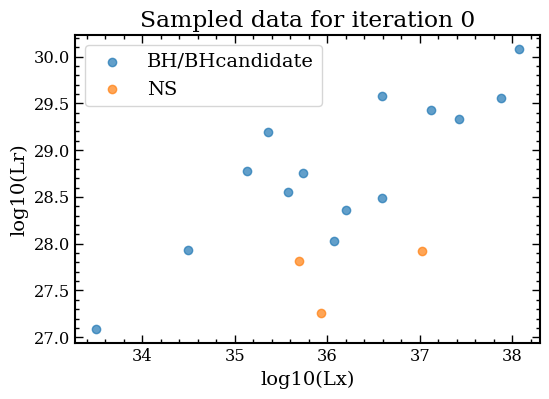

Iteration 2/5: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
p_Lx: 0.8161764705882353 p_Lr: 0.011764705882352941 p_hmp: 0.023195068435900114
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0          1A 1744-361    HS           NS  1.063743e+37  8.333176e+27          False          False
1           4U 1543-47    HS           BH  8.338037e+35  2.233414e+29          False          False
2           4U 1630-47    HS  candidateBH  7.548486e+37  3.585755e+29          False          False
3         EXO 1846-031    HS  candidateBH  2.630214e+37  2.140355e+29          False          False
4         GRS 1739-278    HS  candidateBH  3.763774e+35  3.558757e+28          False          False
5             GX 339-4    HS           BH  2.477485e+35  2.359024e+29          False          False
6            H1743-322    HS  candidateBH  5.616301e+36  9.739400e+28          False          False
7      IGR J17091-3624    HS  candidateBH  1.171203e+38  1.19

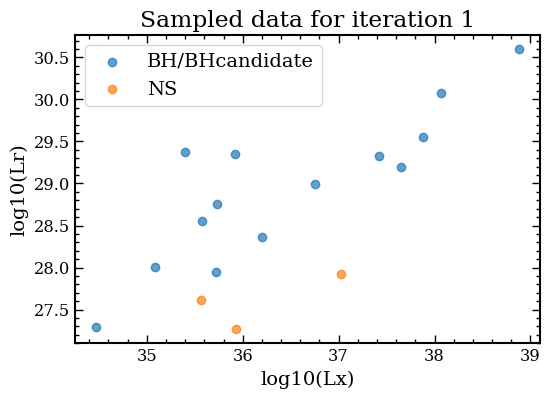

Iteration 3/5: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
p_Lx: 0.8161764705882353 p_Lr: 0.0588235294117647 p_hmp: 0.10973801285219967
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0          1A 1744-361    HS           NS  1.063743e+37  8.333176e+27          False          False
1           4U 1543-47    HS           BH  1.285443e+34  7.812353e+27          False          False
2           4U 1630-47    HS  candidateBH  7.548486e+37  3.585755e+29          False          False
3         EXO 1846-031    HS  candidateBH  2.630214e+37  2.140355e+29          False          False
4         GRS 1739-278    HS  candidateBH  3.763774e+35  3.558757e+28          False          False
5             GX 339-4    HS           BH  1.758266e+34  1.867306e+28          False          False
6            H1743-322    HS  candidateBH  1.889867e+36  3.541600e+28          False          False
7      IGR J17091-3624    HS  candidateBH  1.171203e+38  1.19495

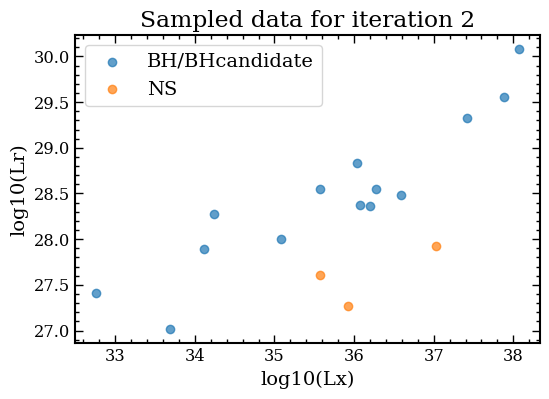

Iteration 4/5: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
p_Lx: 0.8161764705882353 p_Lr: 0.0588235294117647 p_hmp: 0.10973801285219967
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0          1A 1744-361    HS           NS  1.063743e+37  8.333176e+27          False          False
1           4U 1543-47    HS           BH  1.442854e+35  8.214459e+28          False          False
2           4U 1630-47    HS  candidateBH  7.548486e+37  3.585755e+29          False          False
3         EXO 1846-031    HS  candidateBH  2.630214e+37  2.140355e+29          False          False
4         GRS 1739-278    HS  candidateBH  3.763774e+35  3.558757e+28          False          False
5             GX 339-4    HS           BH  1.376130e+34  5.146962e+28          False          False
6            H1743-322    HS  candidateBH  5.616301e+36  9.739400e+28          False          False
7      IGR J17091-3624    HS  candidateBH  1.171203e+38  1.19495

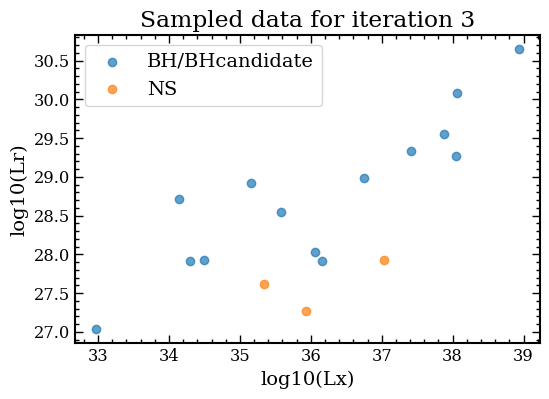

Iteration 5/5: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
p_Lx: 0.9602941176470587 p_Lr: 0.0588235294117647 p_hmp: 0.11085646379764025
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0          1A 1744-361    HS           NS  1.063743e+37  8.333176e+27          False          False
1           4U 1543-47    HS           BH  1.285443e+34  7.812353e+27          False          False
2           4U 1630-47    HS  candidateBH  7.548486e+37  3.585755e+29          False          False
3         EXO 1846-031    HS  candidateBH  2.630214e+37  2.140355e+29          False          False
4         GRS 1739-278    HS  candidateBH  3.763774e+35  3.558757e+28          False          False
5             GX 339-4    HS           BH  2.477485e+35  2.359024e+29          False          False
6            H1743-322    HS  candidateBH  5.616301e+36  9.739400e+28          False          False
7      IGR J17091-3624    HS  candidateBH  1.171203e+38  1.19495

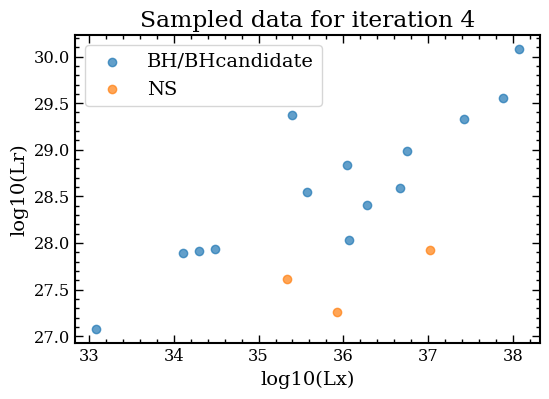

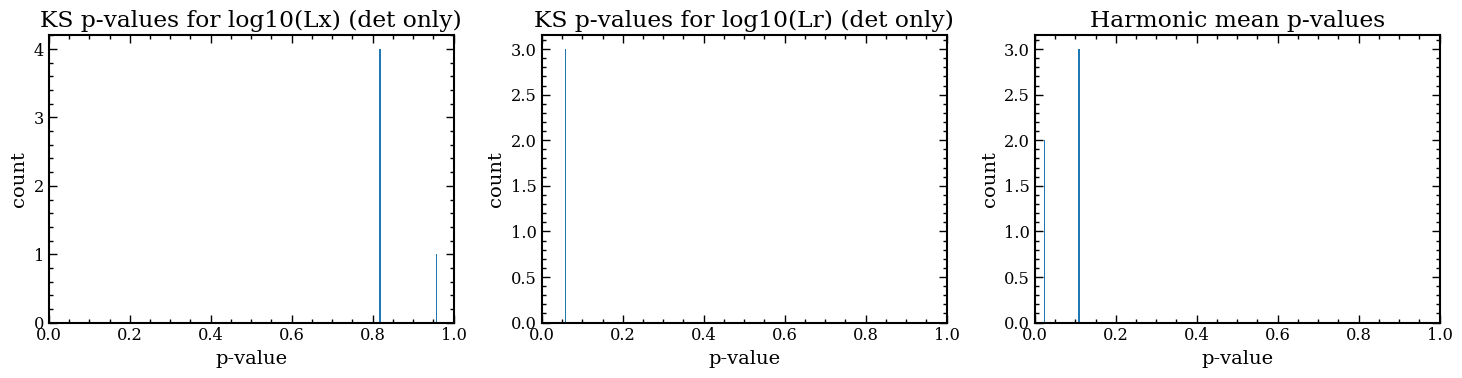


Lx KS
Valid iterations: 5
Fraction with p < 0.05: 0.00%
Fraction with p < 0.01: 0.00%
Fraction with p < 0.001: 0.00%
Median p-value: 8.162e-01
Mean p-value:   8.450e-01

Lr KS
Valid iterations: 5
Fraction with p < 0.05: 40.00%
Fraction with p < 0.01: 0.00%
Fraction with p < 0.001: 0.00%
Median p-value: 5.882e-02
Mean p-value:   4.000e-02

Harmonic mean combined
Valid iterations: 5
Fraction with p < 0.05: 40.00%
Fraction with p < 0.01: 0.00%
Fraction with p < 0.001: 0.00%
Median p-value: 1.097e-01
Mean p-value:   7.534e-02


In [12]:
out = repeated_random_source_sampling_ks(df, n_iter=5, random_seed=None, plot=True)

Iteration 1/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 2/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 3/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 4/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 5/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 6/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 7/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 8/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 9/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 10/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 11/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 12/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 13/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 14/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 15/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
Iteration 16/2000: n1_det=14, n2_det=3, ok_Lx=True, ok_Lr=True
I

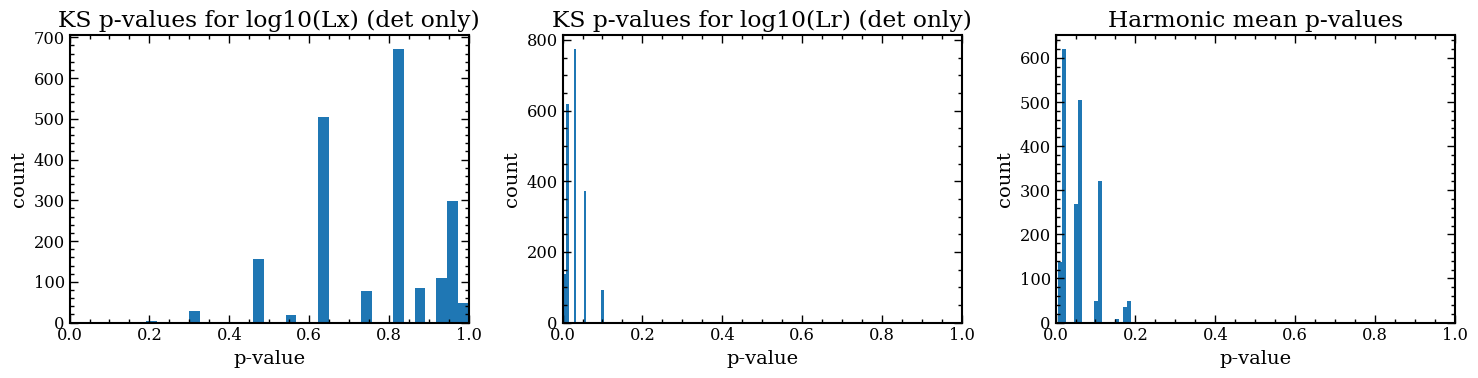


Lx KS
Valid iterations: 2000
Fraction with p < 0.05: 0.00%
Fraction with p < 0.01: 0.00%
Fraction with p < 0.001: 0.00%
Median p-value: 8.162e-01
Mean p-value:   7.677e-01

Lr KS
Valid iterations: 2000
Fraction with p < 0.05: 76.60%
Fraction with p < 0.01: 6.90%
Fraction with p < 0.001: 0.00%
Median p-value: 2.941e-02
Mean p-value:   3.128e-02

Harmonic mean combined
Valid iterations: 2000
Fraction with p < 0.05: 37.90%
Fraction with p < 0.01: 6.90%
Fraction with p < 0.001: 0.00%
Median p-value: 5.627e-02
Mean p-value:   5.851e-02


In [13]:
out = repeated_random_source_sampling_ks(df, n_iter=2000, random_seed=None, plot=False)